# 06 — Audio → Consistent Behavioral Response

**Hypothesis:** sound carries its own meaning — the same audio should induce similar behavioral responses across randomly chosen receivers.

**Data:** `playback_data_combined.xlsx` — keep only rows where all 3 receivers have complete `(MI, BP, D)` (n updates with data).

**Methods:** Euclidean · Cosine · Pearson · ICC · Permutation · LMM · CCA · Mantel

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import mixedlm

np.random.seed(42)
N_PERM = 5000
CHIRP = Path(r"D:\CHIRP")
DATA_PATH = CHIRP / "data" / "playback_data_combined.xlsx"
OUT_DIR = CHIRP / "analysis" / "outputs"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12

## 1. Load & keep complete 3-receiver rows

In [2]:
df_raw = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
print(f"Raw rows: {len(df_raw)}")

beh_cols = [
    "Receiver1MI", "Receiver1BP", "Receiver1D",
    "Receiver2MI", "Receiver2BP", "Receiver2D",
    "Receiver3MI", "Receiver3BP", "Receiver3D",
]
df = df_raw.dropna(subset=beh_cols).copy().reset_index(drop=True)
print(f"Complete 3-receiver rows: {len(df)}")
print("(using all complete 3-receiver rows)")

acoustic_cols = (
    [f"mfcc{i}_mean" for i in range(1, 14)]
    + [f"mfcc{i}_std" for i in range(1, 14)]
    + [f"chroma{i}" for i in range(1, 13)]
    + ["zcr", "rms", "spectral_centroid"]
)
print("Acoustic features:", len(acoustic_cols))
df.head(3)

Raw rows: 316
Complete 3-receiver rows: 307
(using all complete 3-receiver rows)
Acoustic features: 41


,Number,FileName,Sender,SenderBehavior,SenderMI,SenderBP,SenderD,SenderV,SenderA,SenderS,...,chroma11,chroma12,zcr,rms,spectral_centroid,Has2_or_5,pos1,pos2,pos3,pos4
0,1,Aster_alarmrespondingtohuman_1524,1,respondingtohuman,4,-2,-4,-1.8,2.8,-3.2,...,0.590350,0.657865,0.311491,0.064246,4358.639553,1,1,0,0,1
1,2,Aster_alertoncurtain_1906,1,alert,2,1,-2,0.1,1.4,-0.8,...,0.646774,0.564646,0.230179,0.048830,3505.416980,0,0,0,0,0
2,3,Aster_aloneresponding_1458,1,responding,1,0,0,0.1,0.4,0.0,...,0.222277,0.615558,0.329690,0.086895,4209.269147,1,1,1,0,1


## 2. Build receiver vectors & z-score (MI / BP / D)

In [3]:
# Stack all receiver scores to fit a global scaler
all_raw = []
for i in (1, 2, 3):
    all_raw.append(df[[f"Receiver{i}MI", f"Receiver{i}BP", f"Receiver{i}D"]].to_numpy())
all_raw = np.vstack(all_raw)  # (324, 3)

scaler = StandardScaler()
scaler.fit(all_raw)
print("Scaler mean (MI, BP, D):", scaler.mean_.round(3))
print("Scaler std  (MI, BP, D):", scaler.scale_.round(3))

# R[n, 3, 3] = audio × receiver × (MI, BP, D)  — z-scored
R = np.zeros((len(df), 3, 3))
for i in (1, 2, 3):
    raw = df[[f"Receiver{i}MI", f"Receiver{i}BP", f"Receiver{i}D"]].to_numpy()
    R[:, i - 1, :] = scaler.transform(raw)

# Mean behavior vector per audio (for Mantel / CCA Y)
Y_mean = R.mean(axis=1)  # (108, 3)
X_ac = StandardScaler().fit_transform(df[acoustic_cols].to_numpy())
print("R shape:", R.shape, "| Y_mean:", Y_mean.shape, "| X_ac:", X_ac.shape)

Scaler mean (MI, BP, D): [1.25  2.245 1.586]
Scaler std  (MI, BP, D): [1.064 1.025 1.26 ]
R shape: (307, 3, 3) | Y_mean: (307, 3) | X_ac: (307, 41)


## 3. Per-audio: Euclidean / Cosine / Pearson

In [4]:
def pairwise_metrics(vecs):
    """vecs: (3, 3) — 3 receivers × 3 dims. Return mean euclidean, cosine, pearson."""
    pairs = [(0, 1), (0, 2), (1, 2)]
    euc, cos, pear = [], [], []
    for i, j in pairs:
        a, b = vecs[i], vecs[j]
        euc.append(np.linalg.norm(a - b))
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        cos.append(np.dot(a, b) / (na * nb) if na > 0 and nb > 0 else np.nan)
        if np.std(a) > 0 and np.std(b) > 0:
            pear.append(np.corrcoef(a, b)[0, 1])
        else:
            pear.append(np.nan)
    return np.nanmean(euc), np.nanmean(cos), np.nanmean(pear)

rows = []
for idx in range(len(df)):
    d, c, p = pairwise_metrics(R[idx])
    rows.append({
        "Number": df.loc[idx, "Number"],
        "FileName": df.loc[idx, "FileName"],
        "mean_euclidean": d,
        "mean_cosine": c,
        "mean_pearson": p,
    })

per_audio = pd.DataFrame(rows)
print(per_audio[["mean_euclidean", "mean_cosine", "mean_pearson"]].describe().round(3))
per_audio.head()

       mean_euclidean  mean_cosine  mean_pearson
count         307.000      307.000       307.000
mean            1.926        0.169         0.107
std             0.858        0.461         0.447
min             0.000       -0.474        -0.488
25%             1.258       -0.246        -0.313
50%             1.837        0.046         0.014
75%             2.461        0.559         0.439
max             4.439        1.000         1.000


,Number,FileName,mean_euclidean,mean_cosine,mean_pearson
0,1,Aster_alarmrespondingtohuman_1524,2.663700,0.905017,-0.374819
1,2,Aster_alertoncurtain_1906,1.046589,0.316116,0.989204
2,3,Aster_aloneresponding_1458,1.933850,0.456212,-0.364813
3,4,Aster_alonetalking_1335,0.902912,0.949475,-0.323898
4,5,Aster_angryathomeoccupied_1904,2.225328,-0.303573,0.225764


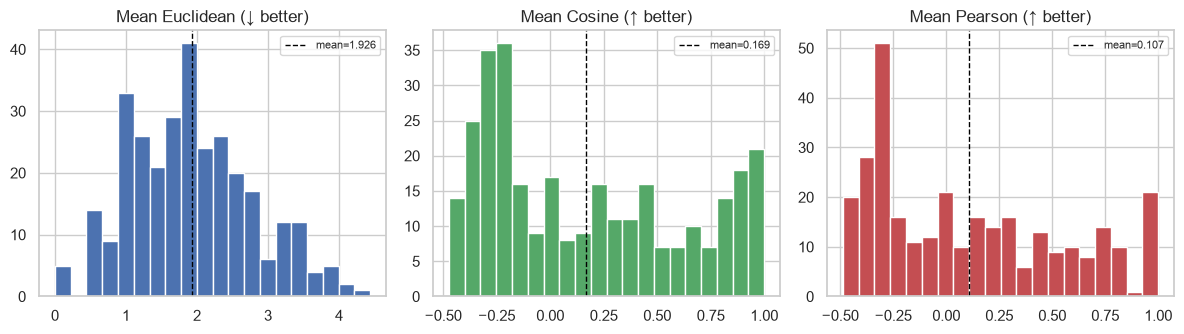

Observed global means — Euclidean: 1.9264 | Cosine: 0.1688 | Pearson: 0.1074


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col, title, color in zip(
    axes,
    ["mean_euclidean", "mean_cosine", "mean_pearson"],
    ["Mean Euclidean (↓ better)", "Mean Cosine (↑ better)", "Mean Pearson (↑ better)"],
    ["#4C72B0", "#55A868", "#C44E52"],
):
    ax.hist(per_audio[col].dropna(), bins=20, color=color, edgecolor="white")
    ax.axvline(per_audio[col].mean(), color="black", ls="--", lw=1, label=f"mean={per_audio[col].mean():.3f}")
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

obs_mean_euc = per_audio["mean_euclidean"].mean()
obs_mean_cos = per_audio["mean_cosine"].mean()
obs_mean_pear = per_audio["mean_pearson"].mean()
print(f"Observed global means — Euclidean: {obs_mean_euc:.4f} | Cosine: {obs_mean_cos:.4f} | Pearson: {obs_mean_pear:.4f}")

## 4. ICC (one-way random effects, per metric)

For each metric (MI / BP / D), treat `FileName` as groups with k=3 receivers:

ICC(1) = (MSB - MSW) / (MSB + (k-1)*MSW)

In [6]:
def icc_oneway(matrix):
    """matrix: (n_groups, k) observations. Returns ICC(1), MSB, MSW."""
    n, k = matrix.shape
    grand = matrix.mean()
    group_means = matrix.mean(axis=1)
    SSB = k * np.sum((group_means - grand) ** 2)
    SSW = np.sum((matrix - group_means[:, None]) ** 2)
    MSB = SSB / (n - 1)
    MSW = SSW / (n * (k - 1))
    icc = (MSB - MSW) / (MSB + (k - 1) * MSW)
    return icc, MSB, MSW

metric_names = ["MI", "BP", "D"]
icc_results = {}
for m, name in enumerate(metric_names):
    mat = R[:, :, m]  # (108, 3)
    icc, msb, msw = icc_oneway(mat)
    icc_results[name] = {"ICC": icc, "MSB": msb, "MSW": msw}
    print(f"{name}: ICC={icc:.4f}  MSB={msb:.4f}  MSW={msw:.4f}")

mean_icc = np.mean([icc_results[n]["ICC"] for n in metric_names])
print(f"\nMean ICC across MI/BP/D: {mean_icc:.4f}")

MI: ICC=0.1111  MSB=1.2238  MSW=0.8901
BP: ICC=0.1515  MSB=1.3048  MSW=0.8497
D: ICC=0.2170  MSB=1.4363  MSW=0.7842

Mean ICC across MI/BP/D: 0.1599


## 5. Permutation tests

Shuffle receiver vectors across audios (destroy audio–response pairing), recompute:
- global mean Euclidean / Cosine / Pearson
- mean ICC

P-values: Euclidean uses left-tail (smaller = more consistent); Cosine / Pearson / ICC use right-tail.

In [7]:
# Pool of all 324 receiver vectors
pool = R.reshape(-1, 3).copy()  # (324, 3)
n_audio = len(df)
k = 3


def stats_from_assignment(R_perm):
    eucs, coss, pears = [], [], []
    for i in range(n_audio):
        d, c, p = pairwise_metrics(R_perm[i])
        eucs.append(d)
        coss.append(c)
        pears.append(p)
    iccs = [icc_oneway(R_perm[:, :, m])[0] for m in range(3)]
    return (
        np.nanmean(eucs),
        np.nanmean(coss),
        np.nanmean(pears),
        np.nanmean(iccs),
    )


rng = np.random.default_rng(42)
null_euc = np.empty(N_PERM)
null_cos = np.empty(N_PERM)
null_pear = np.empty(N_PERM)
null_icc = np.empty(N_PERM)

for b in range(N_PERM):
    shuffled = pool[rng.permutation(len(pool))].reshape(n_audio, k, 3)
    null_euc[b], null_cos[b], null_pear[b], null_icc[b] = stats_from_assignment(shuffled)
    if (b + 1) % 1000 == 0:
        print(f"  permutation {b + 1}/{N_PERM}")

obs_icc = mean_icc

p_euc = (1 + np.sum(null_euc <= obs_mean_euc)) / (N_PERM + 1)
p_cos = (1 + np.sum(null_cos >= obs_mean_cos)) / (N_PERM + 1)
p_pear = (1 + np.sum(null_pear >= obs_mean_pear)) / (N_PERM + 1)
p_icc = (1 + np.sum(null_icc >= obs_icc)) / (N_PERM + 1)

perm_summary = pd.DataFrame([
    {"statistic": "mean_euclidean", "observed": obs_mean_euc, "null_mean": null_euc.mean(), "p": p_euc, "tail": "left"},
    {"statistic": "mean_cosine", "observed": obs_mean_cos, "null_mean": null_cos.mean(), "p": p_cos, "tail": "right"},
    {"statistic": "mean_pearson", "observed": obs_mean_pear, "null_mean": null_pear.mean(), "p": p_pear, "tail": "right"},
    {"statistic": "mean_ICC", "observed": obs_icc, "null_mean": null_icc.mean(), "p": p_icc, "tail": "right"},
])
print(perm_summary.round(4).to_string(index=False))

  permutation 1000/5000


  permutation 2000/5000


  permutation 3000/5000


  permutation 4000/5000


  permutation 5000/5000
     statistic  observed  null_mean      p  tail
mean_euclidean    1.9264     2.1421 0.0002  left
   mean_cosine    0.1688     0.0069 0.0002 right
  mean_pearson    0.1074     0.0189 0.0002 right
      mean_ICC    0.1599     0.0003 0.0002 right


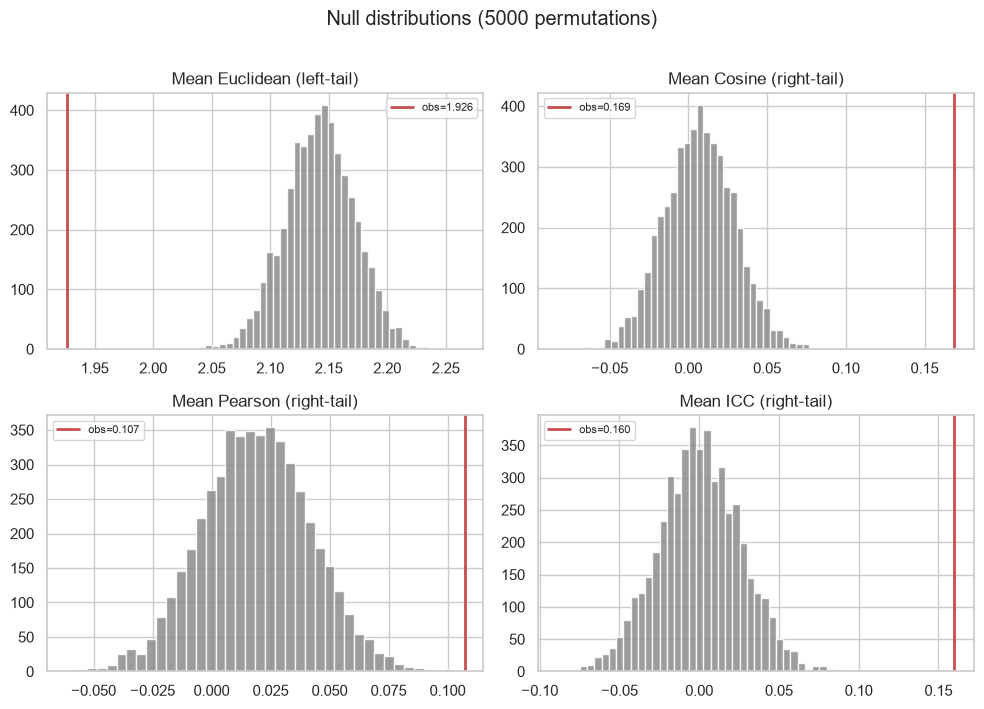

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
specs = [
    (null_euc, obs_mean_euc, "Mean Euclidean", "left"),
    (null_cos, obs_mean_cos, "Mean Cosine", "right"),
    (null_pear, obs_mean_pear, "Mean Pearson", "right"),
    (null_icc, obs_icc, "Mean ICC", "right"),
]
for ax, (null, obs, title, tail) in zip(axes.ravel(), specs):
    ax.hist(null, bins=40, color="#8C8C8C", edgecolor="white", alpha=0.85)
    ax.axvline(obs, color="#C44E52", lw=2, label=f"obs={obs:.3f}")
    ax.set_title(f"{title} ({tail}-tail)")
    ax.legend(fontsize=8)
plt.suptitle(f"Null distributions ({N_PERM} permutations)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Linear Mixed Model

Long format: one row per receiver observation.

```text
y ~ 1 + (1 | FileName)
```

Random-effect ICC = var_audio / (var_audio + var_resid)

In [9]:
long_rows = []
for idx in range(len(df)):
    fname = df.loc[idx, "FileName"]
    for r in range(3):
        long_rows.append({
            "FileName": fname,
            "Receiver": r + 1,
            "MI": R[idx, r, 0],
            "BP": R[idx, r, 1],
            "D": R[idx, r, 2],
        })
long = pd.DataFrame(long_rows)
print(long.shape)
long.head()

(921, 5)


,FileName,Receiver,MI,BP,D
0,Aster_alarmrespondingtohuman_1524,1,0.705175,0.735861,0.328407
1,Aster_alarmrespondingtohuman_1524,2,3.524857,1.711008,2.710004
2,Aster_alarmrespondingtohuman_1524,3,0.705175,0.735861,1.122273
3,Aster_alertoncurtain_1906,1,0.705175,-0.239287,0.328407
4,Aster_alertoncurtain_1906,2,-0.234718,-1.214435,-0.465459


In [10]:
long["audio_id"] = pd.Categorical(long["FileName"]).codes

lmm_rows = []
for metric in metric_names:
    var_audio = var_resid = icc_lmm = intercept = np.nan
    converged = False
    method_used = "anova_fallback"
    try:
        model = mixedlm(f"{metric} ~ 1", long, groups=long["audio_id"])
        fit = model.fit(reml=True, method=["lbfgs", "cg", "powell"], disp=False)
        var_audio = float(np.asarray(fit.cov_re).ravel()[0])
        var_resid = float(fit.scale)
        var_audio = max(var_audio, 0.0)
        var_resid = max(var_resid, 1e-12)
        icc_lmm = var_audio / (var_audio + var_resid)
        intercept = float(fit.fe_params["Intercept"])
        converged = bool(fit.converged)
        method_used = "mixedlm"
        print(f"{metric} MixedLM converged={converged}")
    except Exception as e:
        print(f"{metric} MixedLM failed ({type(e).__name__}: {e}); using ANOVA VC")
        mat = R[:, :, metric_names.index(metric)]
        icc, msb, msw = icc_oneway(mat)
        k_obs = mat.shape[1]
        var_audio = max((msb - msw) / k_obs, 0.0)
        var_resid = msw
        icc_lmm = var_audio / (var_audio + var_resid)
        intercept = float(mat.mean())
        converged = False

    lmm_rows.append({
        "metric": metric,
        "var_audio": var_audio,
        "var_resid": var_resid,
        "ICC_LMM": icc_lmm,
        "intercept": intercept,
        "converged": converged,
        "method": method_used,
    })
    print(f"  -> {metric}: var_audio={var_audio:.4f}, var_resid={var_resid:.4f}, ICC_LMM={icc_lmm:.4f}\n")

lmm_df = pd.DataFrame(lmm_rows)
print(lmm_df.round(4).to_string(index=False))


MI MixedLM failed (LinAlgError: Singular matrix); using ANOVA VC
  -> MI: var_audio=0.1112, var_resid=0.8901, ICC_LMM=0.1111



BP MixedLM failed (LinAlgError: Singular matrix); using ANOVA VC
  -> BP: var_audio=0.1517, var_resid=0.8497, ICC_LMM=0.1515



D MixedLM failed (LinAlgError: Singular matrix); using ANOVA VC
  -> D: var_audio=0.2174, var_resid=0.7842, ICC_LMM=0.2170

metric  var_audio  var_resid  ICC_LMM  intercept  converged         method
    MI     0.1112     0.8901   0.1111       -0.0      False anova_fallback
    BP     0.1517     0.8497   0.1515       -0.0      False anova_fallback
     D     0.2174     0.7842   0.2170       -0.0      False anova_fallback


## 7. Canonical Correlation Analysis (CCA)

X = acoustic features (z-scored), Y = mean receiver behavior vector per audio.

Report first canonical correlation + permutation p-value.

PCA for CCA: 41 -> 10 comps
Canonical correlations: [np.float64(0.3771), np.float64(0.2049), np.float64(0.136)]


  CCA permutation 1000/5000


  CCA permutation 2000/5000


  CCA permutation 3000/5000


  CCA permutation 4000/5000


  CCA permutation 5000/5000

CCA rho1 = 0.3771 | null mean = 0.2323 | p = 0.0008


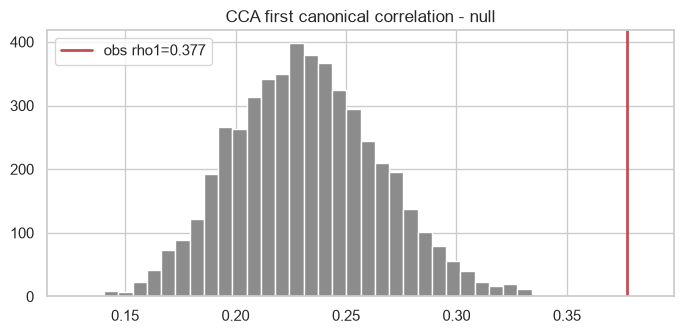

In [11]:
from sklearn.decomposition import PCA

# Reduce acoustics before CCA (n=108, p=41 would inflate rho)
n_pca = min(10, X_ac.shape[0] - 1, X_ac.shape[1])
X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X_ac)
print(f"PCA for CCA: {X_ac.shape[1]} -> {n_pca} comps")

n_components = min(3, X_pca.shape[1], Y_mean.shape[1])
cca = CCA(n_components=n_components, max_iter=500)
Xc, Yc = cca.fit_transform(X_pca, Y_mean)

cca_corrs = [np.corrcoef(Xc[:, i], Yc[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", [round(c, 4) for c in cca_corrs])
obs_cca1 = cca_corrs[0]

null_cca = np.empty(N_PERM)
for b in range(N_PERM):
    Y_shuff = Y_mean[rng.permutation(len(Y_mean))]
    cca_b = CCA(n_components=1, max_iter=300)
    Xb, Yb = cca_b.fit_transform(X_pca, Y_shuff)
    null_cca[b] = np.corrcoef(Xb[:, 0], Yb[:, 0])[0, 1]
    if (b + 1) % 1000 == 0:
        print(f"  CCA permutation {b + 1}/{N_PERM}")

p_cca = (1 + np.sum(null_cca >= obs_cca1)) / (N_PERM + 1)
print(f"\nCCA rho1 = {obs_cca1:.4f} | null mean = {null_cca.mean():.4f} | p = {p_cca:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(null_cca, bins=40, color="#8C8C8C", edgecolor="white")
ax.axvline(obs_cca1, color="#C44E52", lw=2, label=f"obs rho1={obs_cca1:.3f}")
ax.set_title("CCA first canonical correlation - null")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Mantel test

Correlate acoustic distance matrix with behavioral distance matrix (mean response vectors).
Permute row/column labels of one matrix for the null.

Mantel r = 0.0459 | null mean = -0.0004 | p = 0.0508


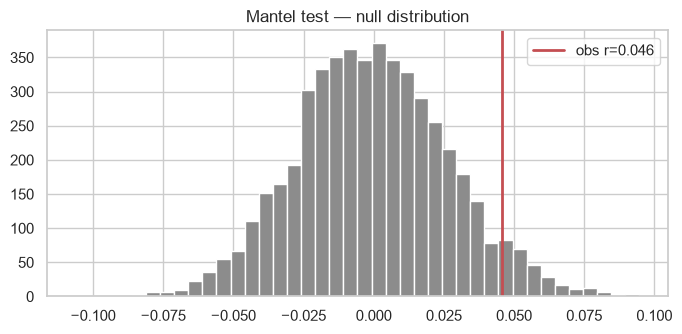

In [12]:
def mantel_test(X, Y, n_perm=N_PERM, metric="euclidean", rng=None):
    """X, Y: (n, p) feature matrices. Returns r_obs, p (right-tail)."""
    if rng is None:
        rng = np.random.default_rng(0)
    Dx = pdist(X, metric=metric)
    Dy = pdist(Y, metric=metric)
    r_obs = np.corrcoef(Dx, Dy)[0, 1]

    n = len(X)
    null = np.empty(n_perm)
    for b in range(n_perm):
        order = rng.permutation(n)
        Dy_perm = pdist(Y[order], metric=metric)
        null[b] = np.corrcoef(Dx, Dy_perm)[0, 1]
    p = (1 + np.sum(null >= r_obs)) / (n_perm + 1)
    return r_obs, p, null

mantel_r, mantel_p, null_mantel = mantel_test(X_ac, Y_mean, n_perm=N_PERM, rng=rng)
print(f"Mantel r = {mantel_r:.4f} | null mean = {null_mantel.mean():.4f} | p = {mantel_p:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(null_mantel, bins=40, color="#8C8C8C", edgecolor="white")
ax.axvline(mantel_r, color="#C44E52", lw=2, label=f"obs r={mantel_r:.3f}")
ax.set_title("Mantel test — null distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary table + save outputs

In [13]:
summary = pd.DataFrame([
    {"layer": "within-audio", "method": "Euclidean (mean)", "estimate": obs_mean_euc, "p_perm": p_euc, "note": "lower = more consistent"},
    {"layer": "within-audio", "method": "Cosine (mean)", "estimate": obs_mean_cos, "p_perm": p_cos, "note": "higher = more consistent"},
    {"layer": "within-audio", "method": "Pearson (mean)", "estimate": obs_mean_pear, "p_perm": p_pear, "note": "higher = more consistent"},
    {"layer": "within-audio", "method": "ICC mean (MI/BP/D)", "estimate": obs_icc, "p_perm": p_icc, "note": "higher = more consistent"},
    {"layer": "within-audio", "method": "LMM/ANOVA ICC mean", "estimate": lmm_df["ICC_LMM"].mean(), "p_perm": np.nan, "note": "var_audio / total (balanced = ANOVA VC)"},
    {"layer": "acoustic-behavior", "method": "CCA rho1", "estimate": float(obs_cca1), "p_perm": p_cca, "note": "acoustic predicts mean behavior"},
    {"layer": "acoustic-behavior", "method": "Mantel r", "estimate": mantel_r, "p_perm": mantel_p, "note": "distance-distance correlation"},
])

print(f"=== Hypothesis test summary (n={len(df)} complete audios) ===")
print(summary.round(4).to_string(index=False))
print("\nPer-metric ICC (ANOVA):")
print(pd.DataFrame(icc_results).T.round(4))
print("\nPer-metric LMM/ANOVA ICC:")
print(lmm_df.round(4).to_string(index=False))

per_audio.to_csv(OUT_DIR / "consistency_per_audio.csv", index=False)
summary.to_csv(OUT_DIR / "consistency_summary.csv", index=False)
lmm_df.to_csv(OUT_DIR / "consistency_lmm.csv", index=False)
print("\nSaved: consistency_per_audio.csv | consistency_summary.csv | consistency_lmm.csv")


=== Hypothesis test summary (n=307 complete audios) ===
            layer             method  estimate  p_perm                                    note
     within-audio   Euclidean (mean)    1.9264  0.0002                 lower = more consistent
     within-audio      Cosine (mean)    0.1688  0.0002                higher = more consistent
     within-audio     Pearson (mean)    0.1074  0.0002                higher = more consistent
     within-audio ICC mean (MI/BP/D)    0.1599  0.0002                higher = more consistent
     within-audio LMM/ANOVA ICC mean    0.1599     NaN var_audio / total (balanced = ANOVA VC)
acoustic-behavior           CCA rho1    0.3771  0.0008         acoustic predicts mean behavior
acoustic-behavior           Mantel r    0.0459  0.0508           distance-distance correlation

Per-metric ICC (ANOVA):
       ICC     MSB     MSW
MI  0.1111  1.2238  0.8901
BP  0.1515  1.3048  0.8497
D   0.2170  1.4363  0.7842

Per-metric LMM/ANOVA ICC:
metric  var_audio  var_r